The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


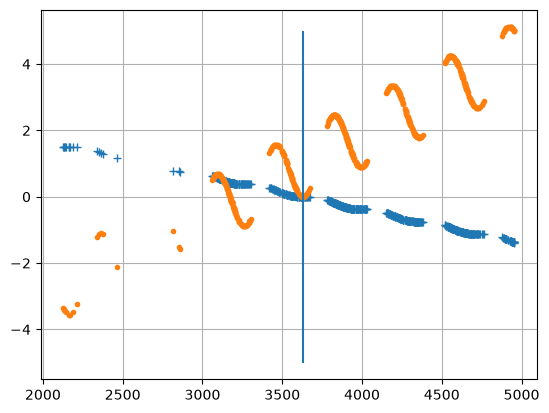

In [22]:
%load_ext autoreload
%autoreload 2

import numpy as np
import os
import matplotlib.pyplot as plt
os.chdir("/Users/tcorey/Desktop/microlensing")
from lc_models import sun_earth_projection
from mcmc_fit import fit_pspl_mcmc
from astropy.coordinates import SkyCoord
time, mag, mag_err = np.loadtxt("data/OGLE-2005-BLG-086.dat", unpack=True)
best_fit = fit_pspl_mcmc(time, mag, mag_err, run_mcmc=False)
ra = "18h04m45.70s"
dec = "-26d59m15.5s"
coords = SkyCoord(ra + " " + dec)
delta_sN, delta_sE = sun_earth_projection(time, coords, best_fit.best_fit[0])
plt.plot(time, delta_sN, "+")
plt.plot(time, delta_sE, ".")
plt.vlines(best_fit.best_fit[0], -5, 5)
plt.grid(True)

In [23]:
# Plotting-style check for the 2L1S track -- reuses saved MCMC chains (.npz) instead of
# rerunning run_mcmc()/run_mcmc_chi2() (each a real ~15min sampler run) just to eyeball a plot.
import sys
sys.path.insert(0, "/Users/tcorey/Desktop/microlensing/scratch")  # absolute, not relative -- relative "scratch"
                                # depends on cwd already being the project root, which needs this notebook's
                                # own os.chdir() cell above to have actually run first in this kernel session.

import numpy as np
from IPython.display import Image

from fit_2l1s import plot_fit, SHORT_NAME  # module-level setup here is one quick PSPL fit, not the multi-start search

def best_from_chain(path):
    d = np.load(path)
    return d["samples"][np.argmax(d["log_probs"])]

# every plot_fit call below uses a "_stylecheck" suffix on the tag, so this never overwrites
# the real run's saved plot at its own canonical filename.

/Users/tcorey/Desktop/microlensing/scratch/fit_2l1s.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  return (moa_flux - fs_moa * (A_moa - 1.0)) / moa_flux_err


saved scratch/O-03-BLG235_2l1s_mcmc_studentt_stylecheck.png


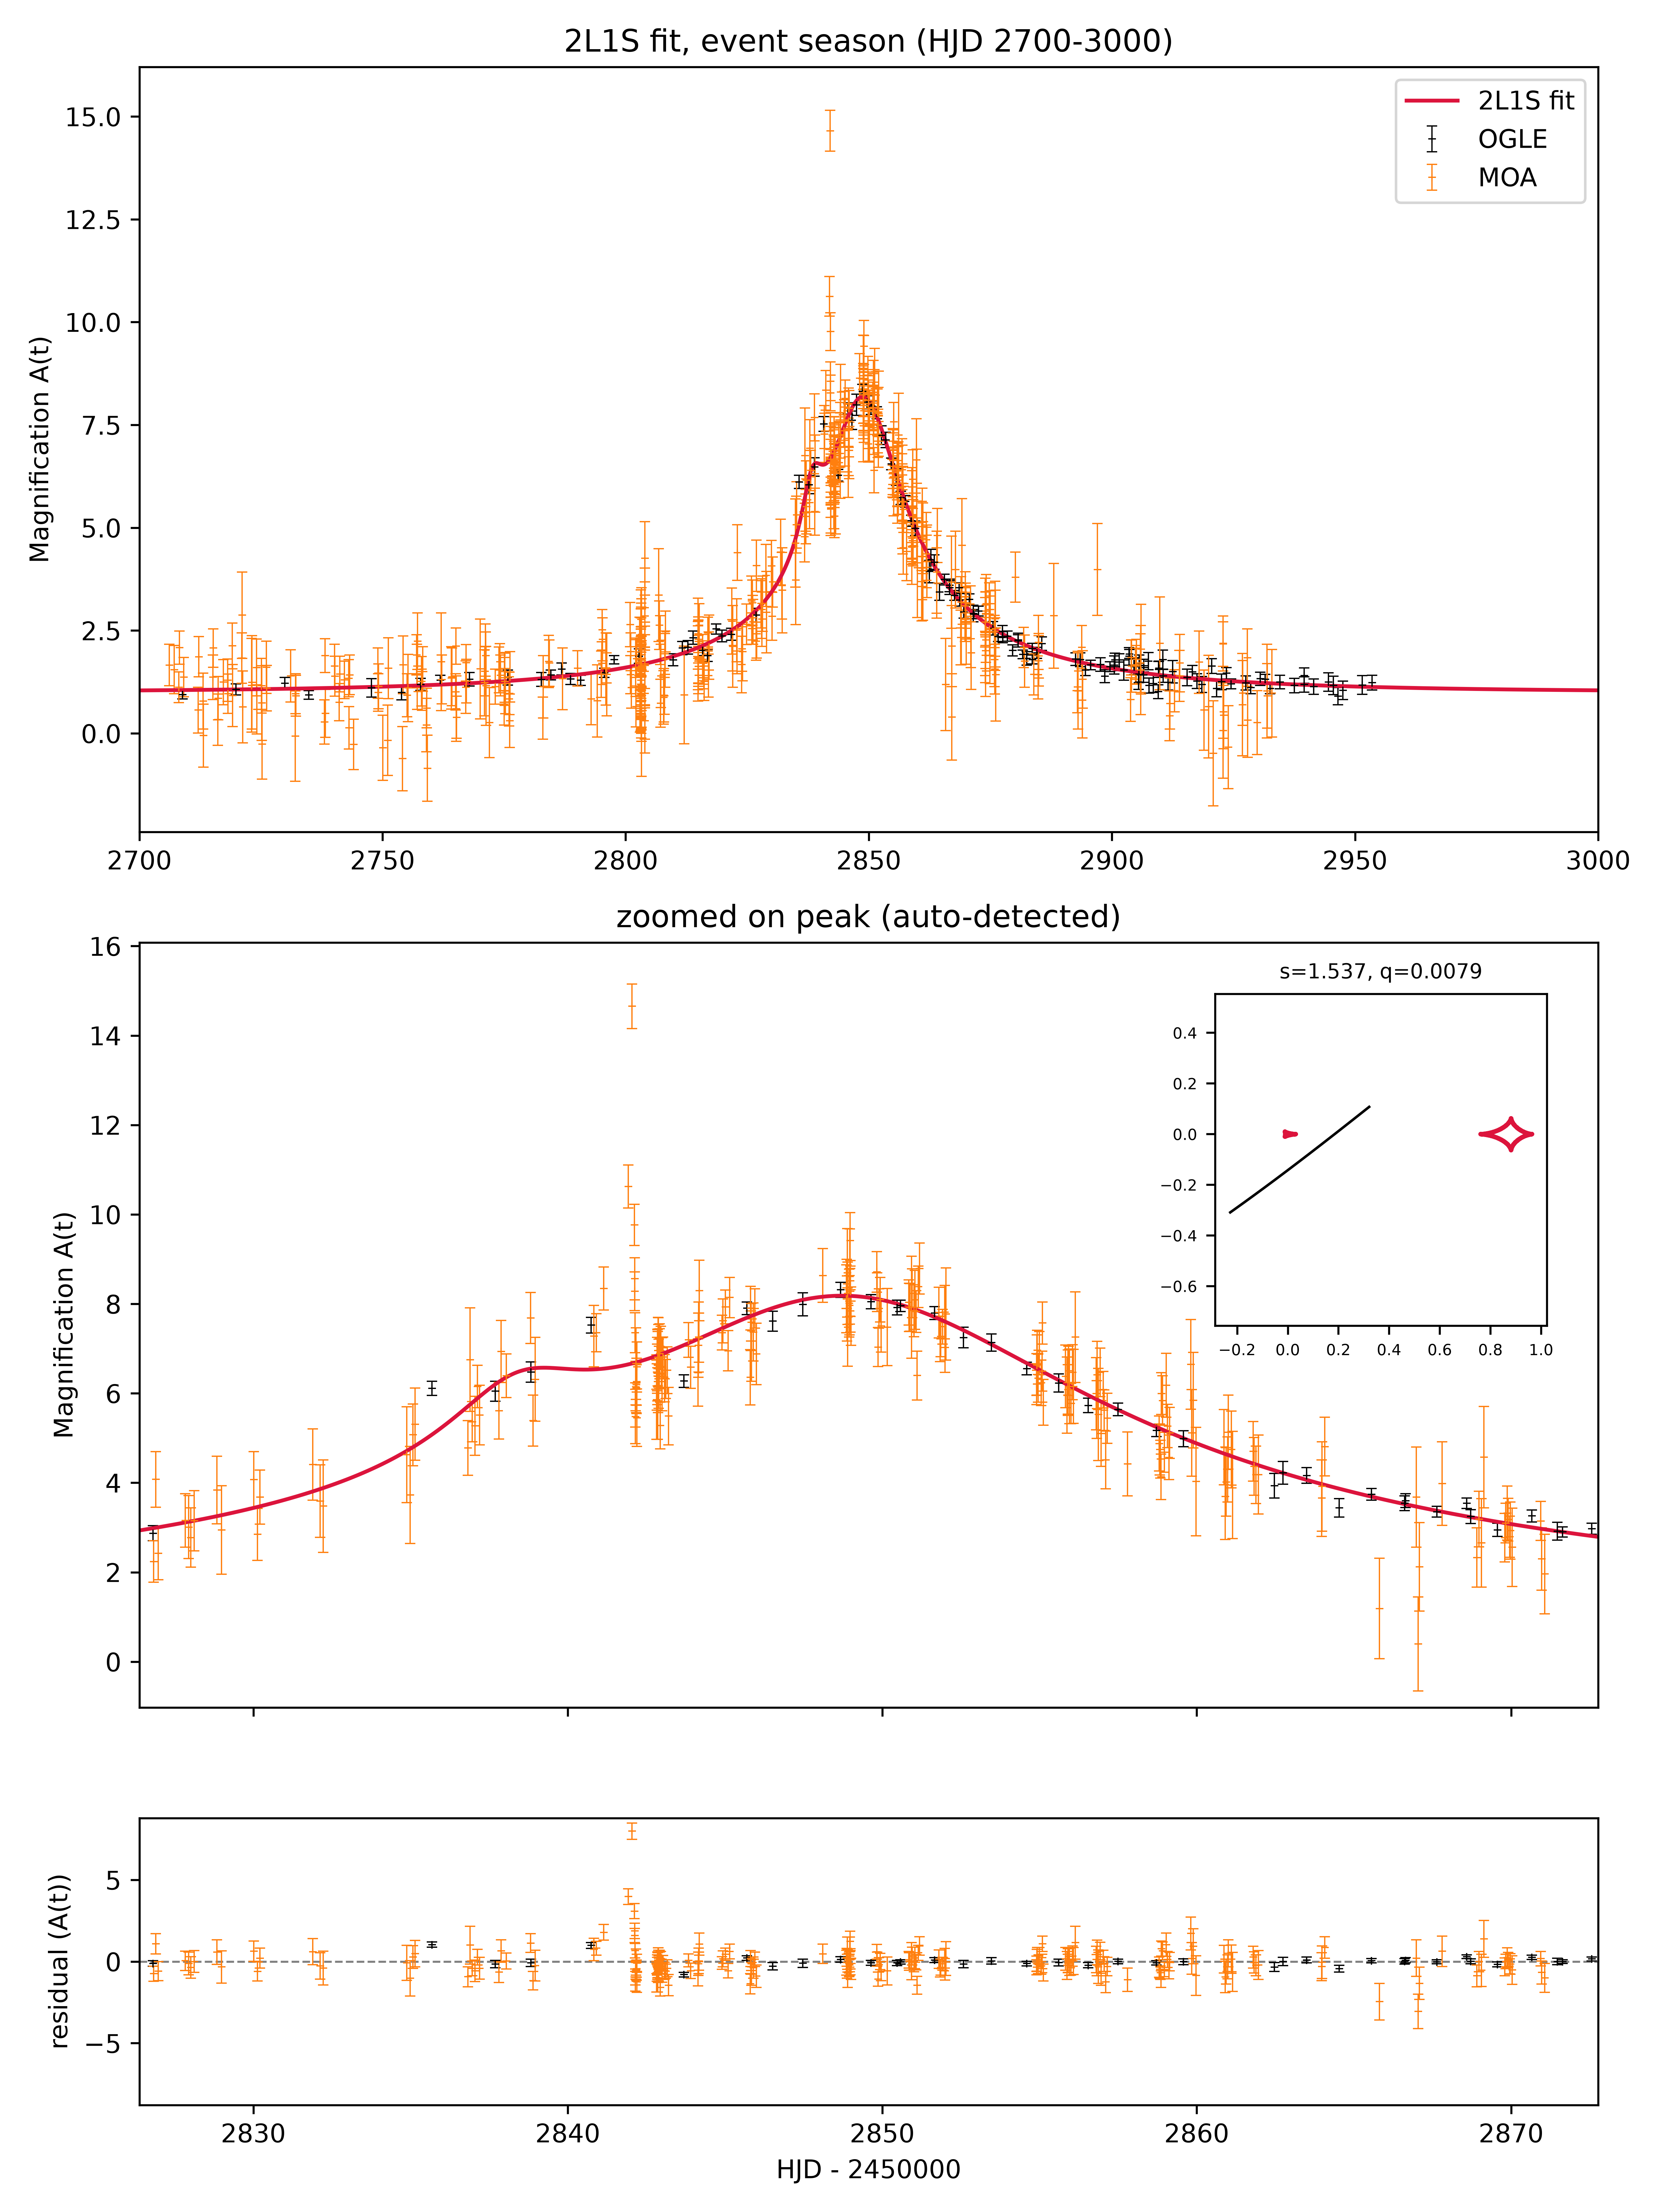

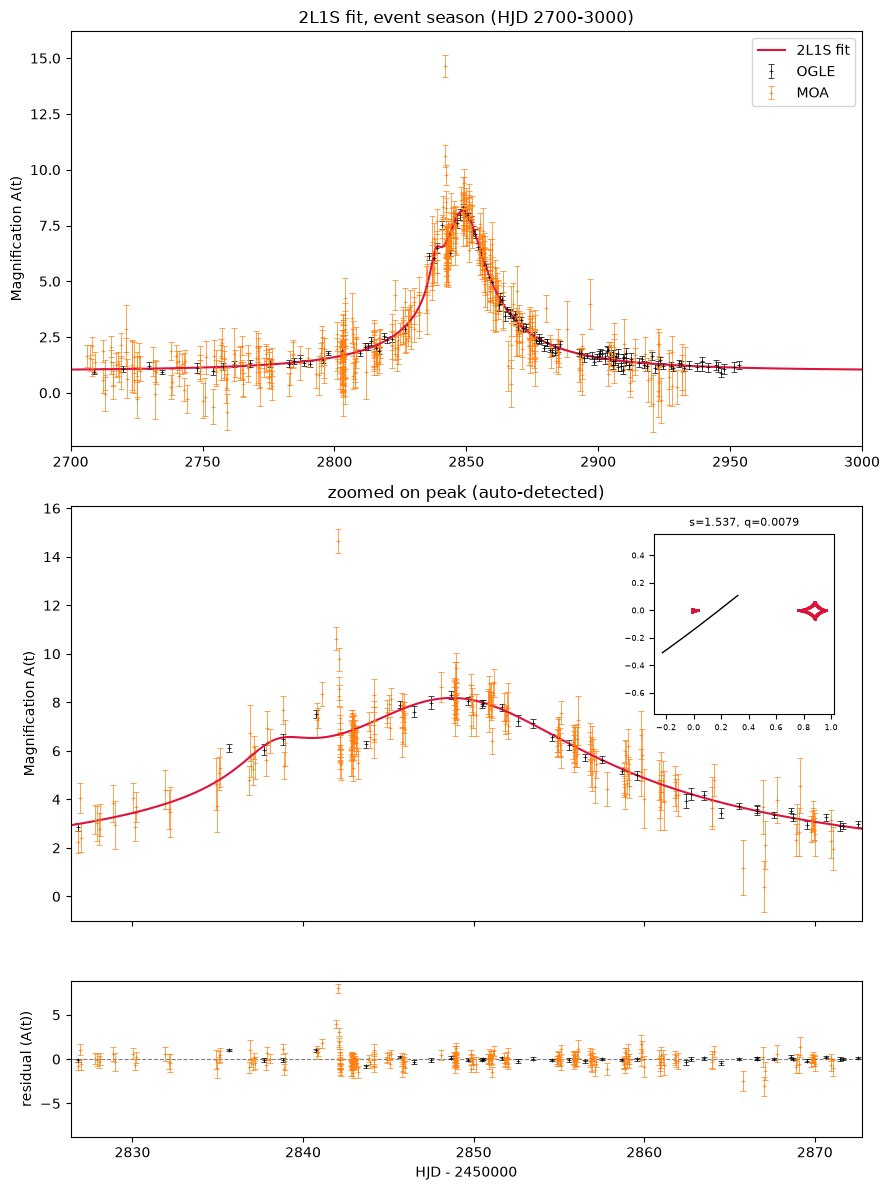

In [24]:
# Student-t, joint (OGLE+MOA) -- from run_mcmc()
best = best_from_chain("scratch/O-03-BLG235_2l1s_mcmc_chain.npz")
plot_fit(best[:8], use_ogle=True, tag="_mcmc_studentt_stylecheck")  # best has scale/dof -- plot_fit takes only the 8 physical params; plot_fit() itself has no return value, it just saves to disk
Image(filename=f"scratch/{SHORT_NAME}_2l1s_mcmc_studentt_stylecheck.png")

saved scratch/O-03-BLG235_2l1s_mcmc_chi2_stylecheck.png


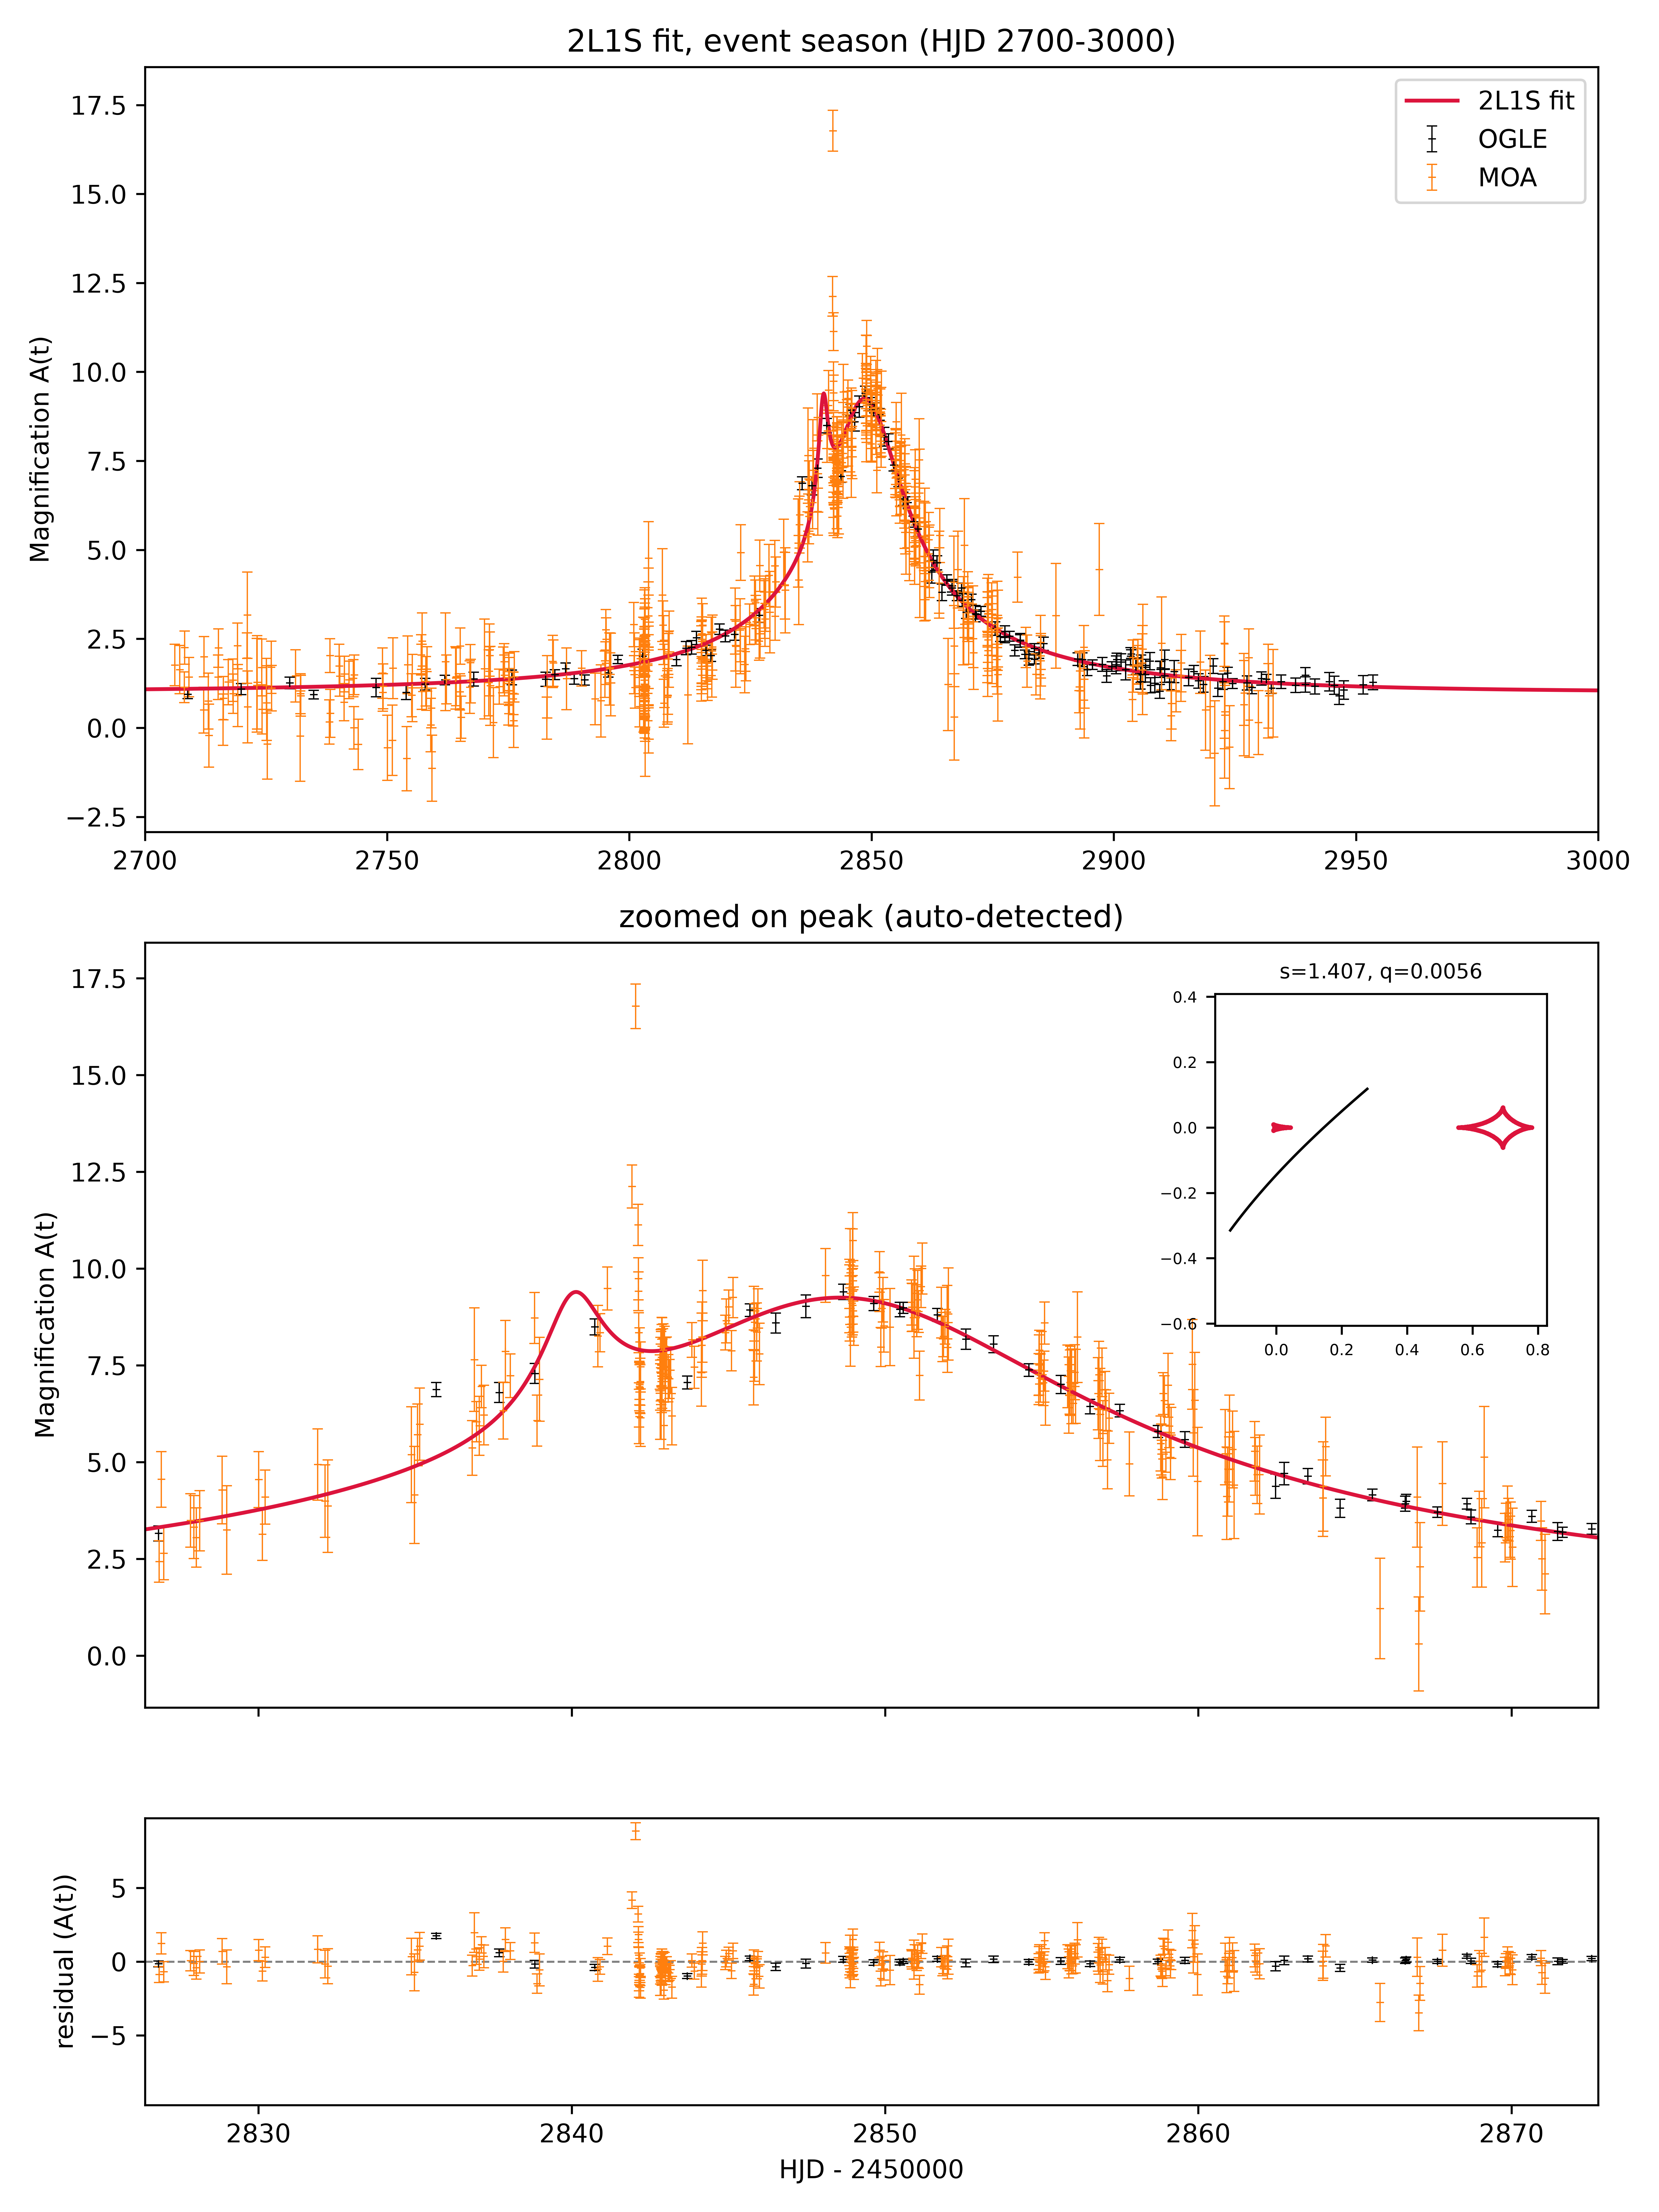

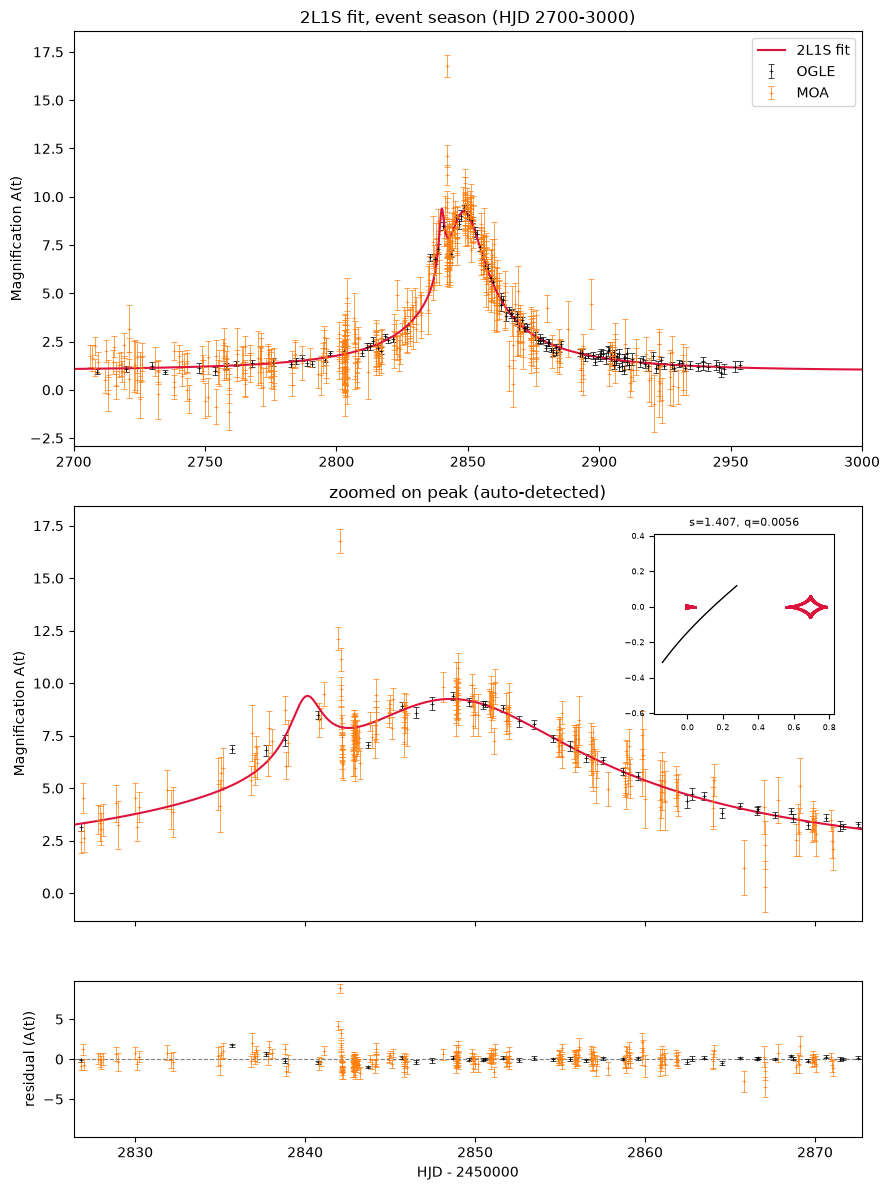

In [25]:
# Gaussian chi2, joint -- from run_mcmc_chi2(). LABELS_CHI2 has no scale/dof, so no slicing needed.
best = best_from_chain("scratch/O-03-BLG235_2l1s_mcmc_chain_chi2.npz")
plot_fit(best, use_ogle=True, tag="_mcmc_chi2_stylecheck")
Image(filename=f"scratch/{SHORT_NAME}_2l1s_mcmc_chi2_stylecheck.png")

saved scratch/O-03-BLG235_2l1s_moa_only_mcmc_studentt_stylecheck.png


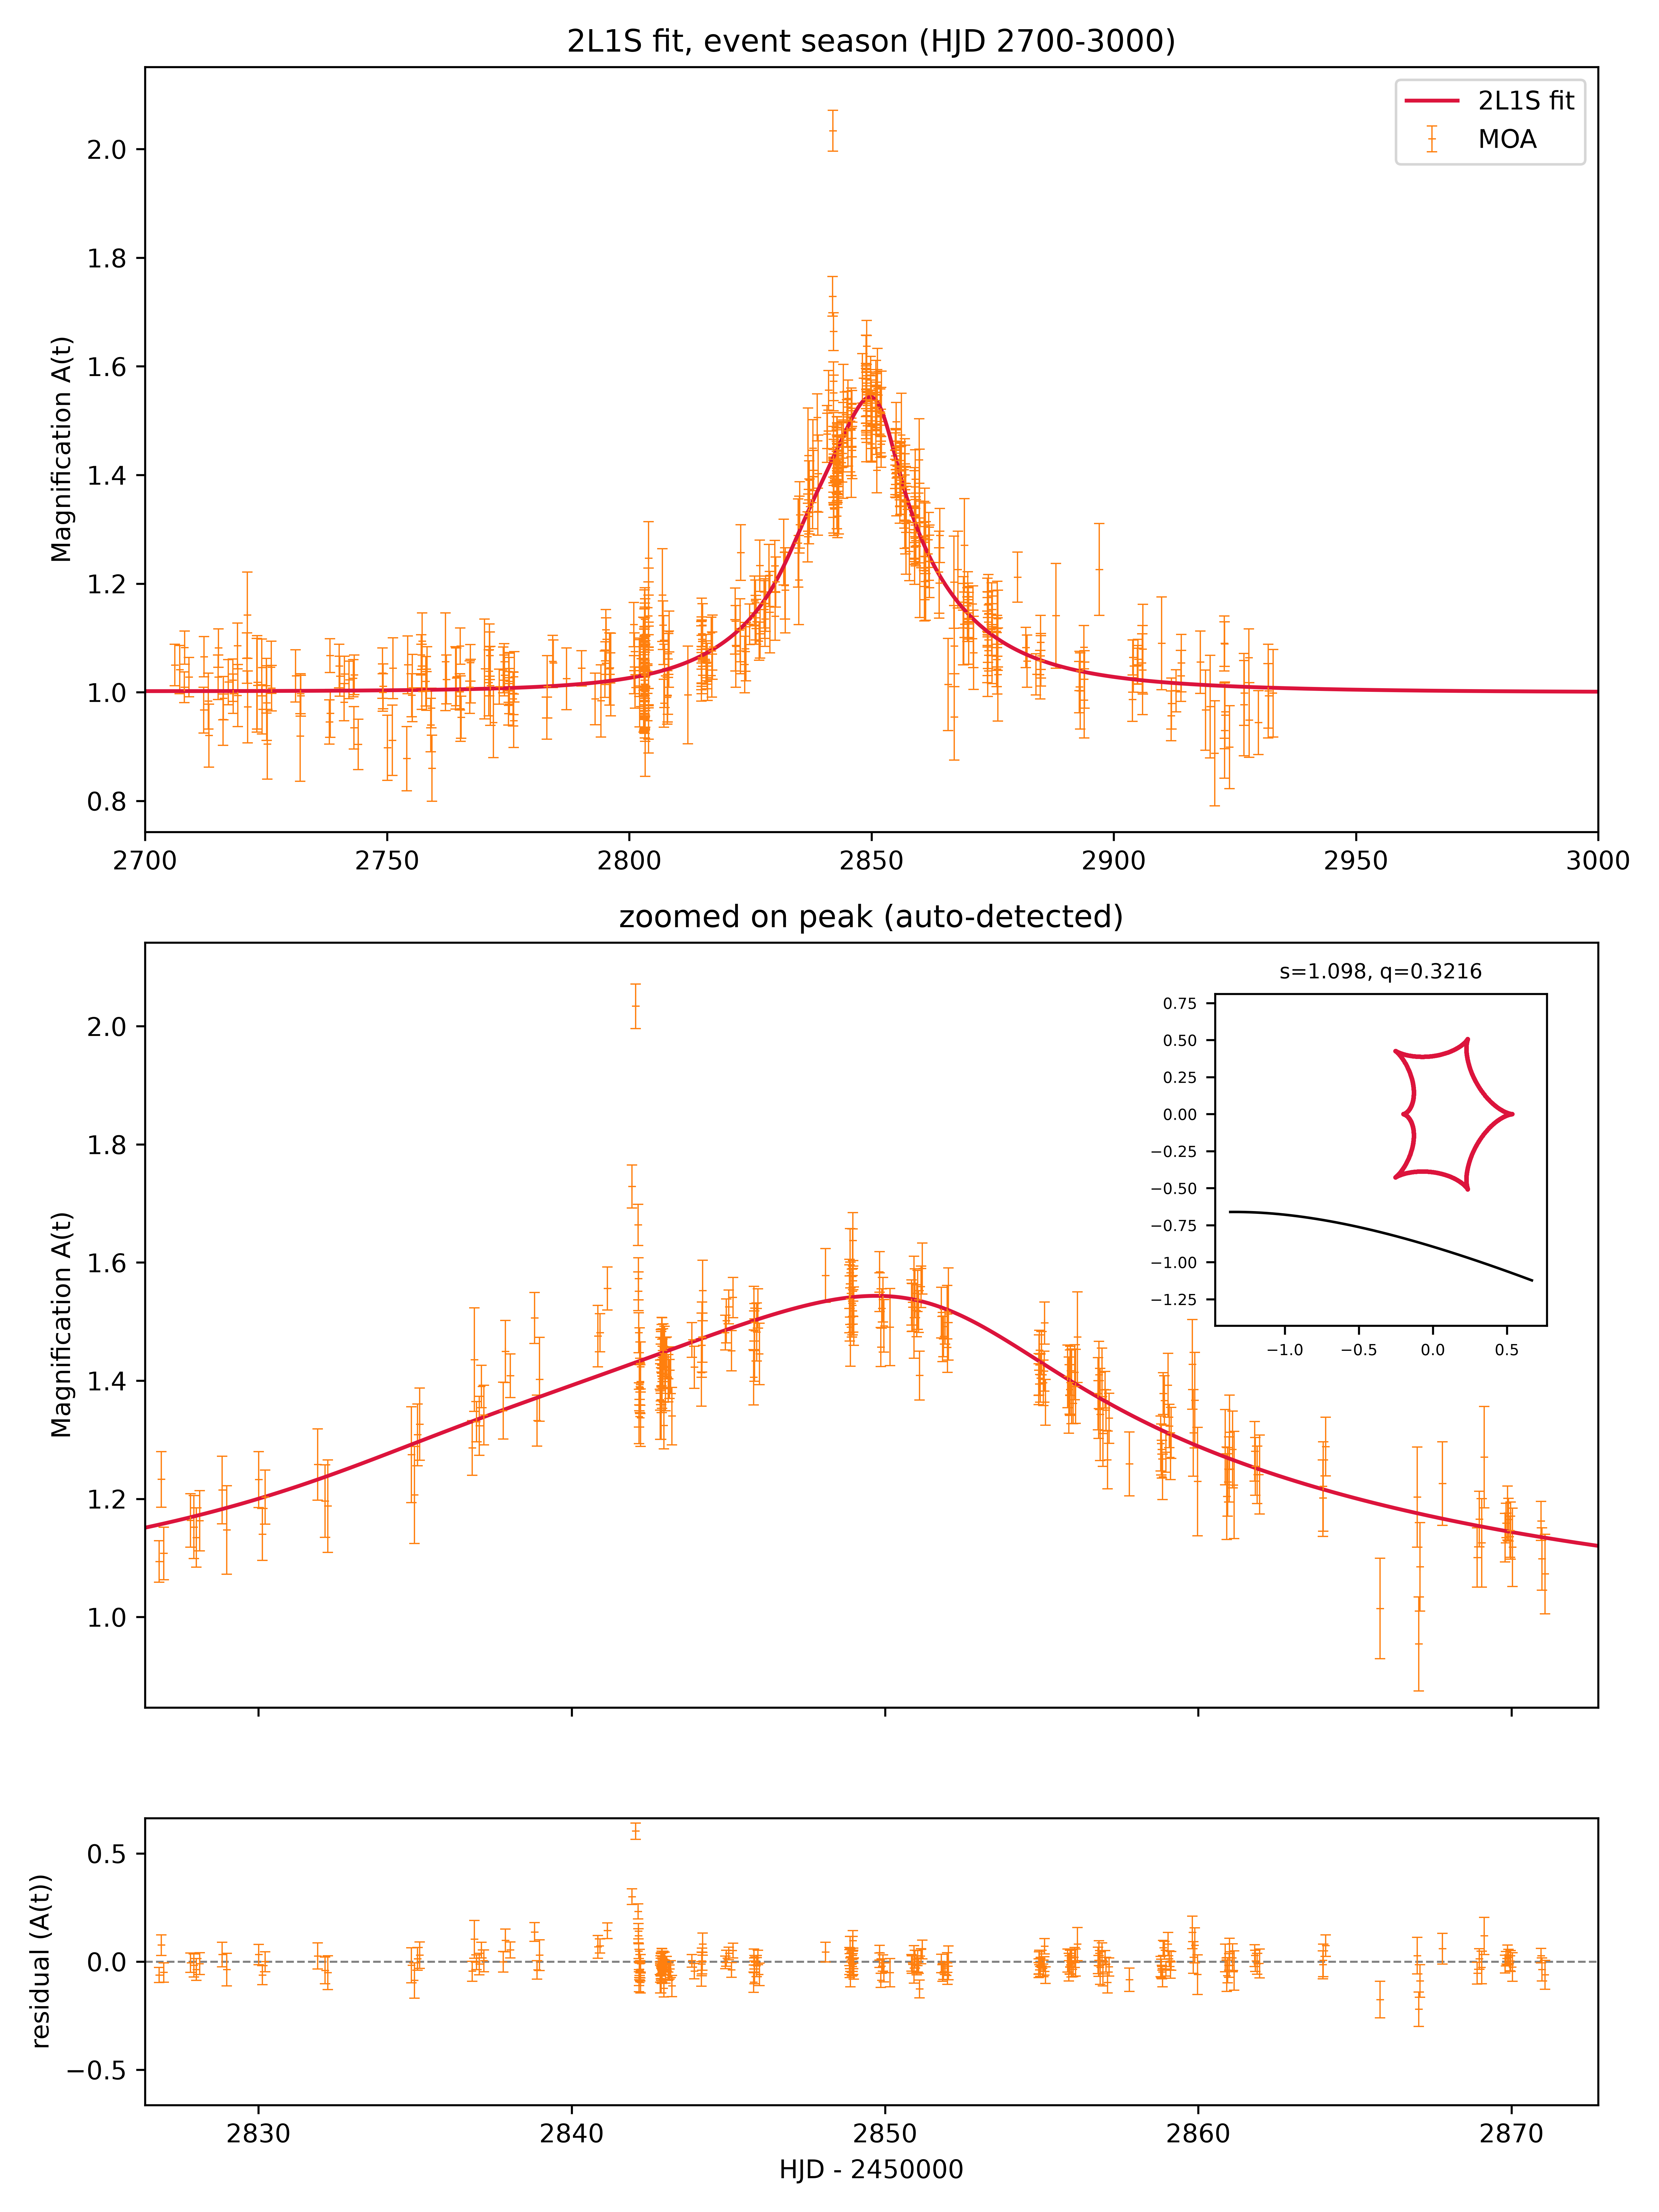

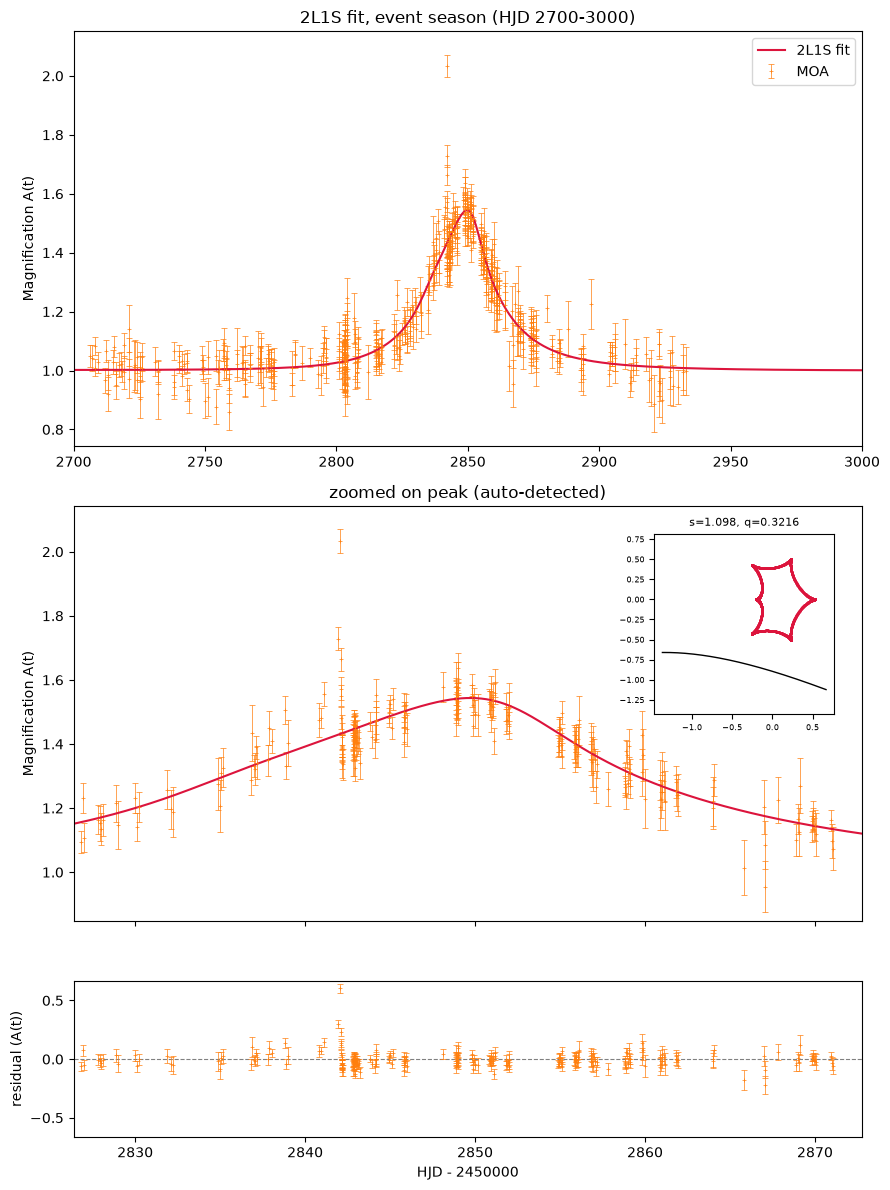

In [26]:
# Student-t, MOA-only -- from run_mcmc_moa_only()
best = best_from_chain("scratch/O-03-BLG235_2l1s_mcmc_chain_moa_only.npz")
plot_fit(best[:8], use_ogle=False, tag="_mcmc_studentt_stylecheck")
Image(filename=f"scratch/{SHORT_NAME}_2l1s_moa_only_mcmc_studentt_stylecheck.png")

No `scratch/O-03-BLG235_2l1s_mcmc_chain_huber.npz` yet -- `run_mcmc_huber()` hasn't actually been run.
Once it has, add the same three lines with that path and `tag="_mcmc_huber_stylecheck"`.
No saved chain exists for `run_fit()` (Nelder-Mead) either -- it never persists one, so its plot style can only be checked by actually calling `run_fit()`.